<h2>Лабораторна робота №6</h2>
<h3>Нейро-нечітке моделювання</h3>

Обробка даних РТС...
Обробка даних валют (DEXUSEU)...


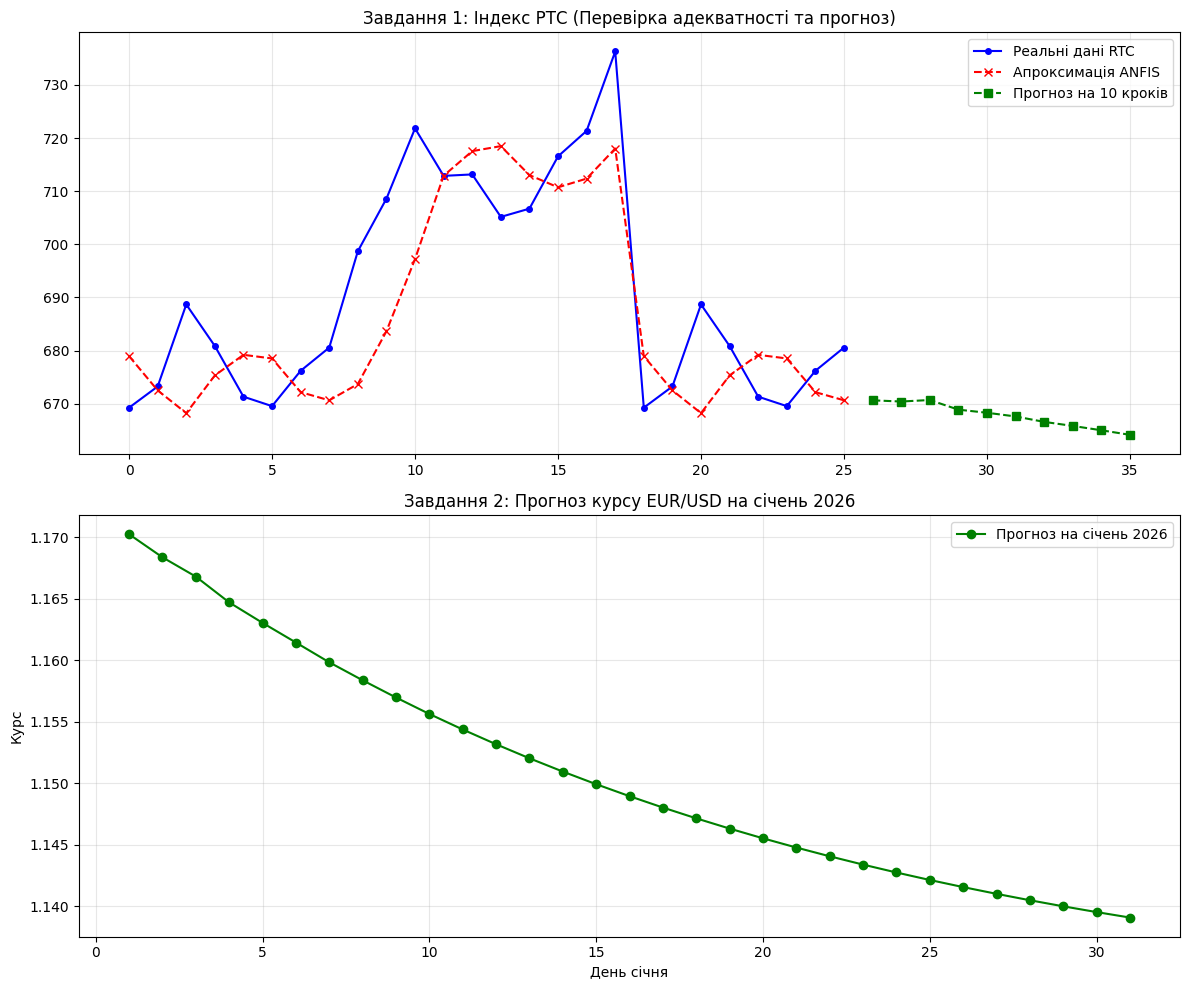

Прогноз РТС (10 кроків): [670.64 670.42 670.7  668.89 668.31 667.61 666.59 665.83 665.01 664.15]
Середній курс EUR/USD на січень 2026: 1.1510


In [2]:
import pandas as pd # Імпортується бібліотека pandas для роботи з таблицями та CSV-файлами
import numpy as np  # Імпортується NumPy для чисельних обчислень, роботи з масивами та формулами
import matplotlib.pyplot as plt # Імпортується matplotlib для побудови графіків

# 1. ФУНКЦІЇ ДЛЯ МОДЕЛЮВАННЯ ШАРІВ ANFIS (TSK)

# Оголошується функція гаусової (нормальної) функції приналежності
def gauss_mf(x, mean, sigma): 
# Шар 1: Фазифікація (Гауссова функція приналежності)
# Обчислює ступінь приналежності x до нечіткої множини за формулою гауссової функції
    return np.exp(-((x - mean)**2) / (2 * sigma**2)) 

# Функція прогнозує вихід ANFIS для одного вхідного вектора: input_row — вхідні змінні
# mf_params — параметри функцій приналежності, tsk_params — параметри TSK-правил
def anfis_predict(input_row, mf_params, tsk_params):
# Реалізація 5-шарової структури TSK
# Шар 2: Агрегування
    w = [] # Створюється список для збереження сили спрацювання правил
    for i in range(len(mf_params)): # Проходимо у циклі по всіх нечітких правилах
        # Обчислюється сила правила як добуток ступенів приналежності
        # Для кожної змінної обчислюється її ступінь приналежності
        # Цикл по всіх вхідних змінних: for j in range(len(input_row))
        rule_strength = np.prod([gauss_mf(input_row[j], mf_params[i][j][0], mf_params[i][j][1]) 
                                 for j in range(len(input_row))])
        w.append(rule_strength) # Додається сила правила до списку
    
    w = np.array(w) # Перетворюється список сил правил у NumPy-масив
    sum_w = np.sum(w) if np.sum(w) != 0 else 1 # Обчислюється сума всіх сил правил
    
# Шар 3, 4, 5: Нормалізація та вихід
    output = 0 # Початкове значення виходу моделі
    for i in range(len(w)): # Проходимо по всіх правилах
        w_norm = w[i] / sum_w # Нормалізована сила правила
        # Лінійна TSK-функція: f=a0+a1*x1+a2*x2+...
        f = tsk_params[i][0] + np.sum(tsk_params[i][1:] * input_row) 
        output += w_norm * f # Вклад цього правила у фінальний результат
    return output # Повертається прогноз ANFIS

# 2. ЗАВДАННЯ 1: ПРОГНОЗ ІНДЕКСУ РТС ТА ПЕРЕВІРКА АДЕКВАТНОСТІ

print("Обробка даних РТС...") # Повідомлення про початок обробки даних
df_rtc = pd.read_csv('RTCFinanceIndex.csv') # Зчитування CSV-файлу з даними РТС
for col in df_rtc.columns: # Перебір усіх колонок таблиці
    if df_rtc[col].dtype == 'object': # Якщо дані зчитались як текст
        # Видаляються лапки та перетворюємо у числа
        df_rtc[col] = df_rtc[col].str.replace('"', '').astype(float)

# Формування матриці вхідних змінних
X_rtc = df_rtc[['InputVariable1', 'InputVariable2', 'InputVariable3']].values
# Реальні значення виходу (еталон)
Y_rtc_actual = df_rtc['OutputVariable'].values

# Параметри (емова навчання)
# Параметри гаусових функцій приналежності (середнє, σ)
mf_rtc = [[(685, 20), (680, 20), (675, 20)], [(710, 20), (715, 20), (720, 20)]]
# Параметри TSK-правил
tsk_rtc = [[5, 0.33, 0.33, 0.33], [10, 0.30, 0.35, 0.34]]

# Прогноз ANFIS для кожного рядка даних
Y_rtc_pred = [anfis_predict(row, mf_rtc, tsk_rtc) for row in X_rtc]

# Майбутній прогноз РТС на 10 кроків
future_rtc = [] # Список прогнозних значень
last_win_rtc = list(X_rtc[-1]) # Останнє вікно значень як старт прогнозу
for _ in range(10): # Прогноз на 10 кроків вперед
    p = anfis_predict(np.array(last_win_rtc), mf_rtc, tsk_rtc) # Обчислення прогнозу
    future_rtc.append(p) # Збереження прогнозу
    # Зсув вікна (ковзне вікно)
    # last_win_rtc — початкове вікно з 3 останніх значень, p — прогноз наступного значення
    # last_win_rtc[1:] — відкидаємо найстаріше, + [p] — додаємо новий прогноз
    last_win_rtc = last_win_rtc[1:] + [p] 

# 3. ЗАВДАННЯ 2: КУРС ЄВРО ДО ДОЛАРА (СІЧЕНЬ 2026)

print("Обробка даних валют (DEXUSEU)...") # Повідомлення про початок обробки даних
df_fx = pd.read_csv('DEXUSEU.csv') # Зчитування курсу EUR/USD
df_fx['DEXUSEU'] = pd.to_numeric(df_fx['DEXUSEU'], errors='coerce') # Перетворення у числовий формат
df_fx = df_fx.dropna() # Видалення пропущених значень

fx_data = df_fx['DEXUSEU'].values # Масив значень курсу
avg_fx = np.mean(fx_data) # Середнє значення курсу

# Налаштування параметрів під валютний курс
# Гаусові функції приналежності для валютного курсу
mf_fx = [[(avg_fx, 0.05), (avg_fx, 0.05), (avg_fx, 0.05)]]
tsk_fx = [[avg_fx * 0.1, 0.3, 0.3, 0.3]] # TSK-модель з акцентом на тренд

# Прогноз на січень 2026 (31 день)
jan_forecast = [] # Список прогнозів на січень
last_win_fx = fx_data[-3:] # Початкове вікно значень
for _ in range(31): # Прогноз на 31 день
    p = anfis_predict(last_win_fx, mf_fx, tsk_fx) # Прогноз одного дня
    jan_forecast.append(p) # Збереження результату
    # Оновлення вікна
    # last_win[1:] → прибрати найстаріший елемент, + [p] → додати нове значення (прогноз)
    last_win_fx = np.append(last_win_fx[1:], p) 

# 4. ВІЗУАЛІЗАЦІЯ

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10)) # Створення двох графіків в одному вікні

# Графік 1: РТС (Адекватність + Прогноз)
# Побудова графіка з реальними даних
ax1.plot(df_rtc.index, Y_rtc_actual, 'b-o', label='Реальні дані RTC', markersize=4)
# Побудова графіка з апроксимованими даними
ax1.plot(df_rtc.index, Y_rtc_pred, 'r--x', label='Апроксимація ANFIS')
# Створюється масив індексів для 10 майбутніх значень часового ряду, які йдуть після наявних даних РТС
future_idx = np.arange(len(df_rtc), len(df_rtc) + 10)
# Побудова графіка з прогнозними даними
ax1.plot(future_idx, future_rtc, 'g--s', label='Прогноз на 10 кроків')

ax1.set_title('Завдання 1: Індекс РТС (Перевірка адекватності та прогноз)') # Надається назву графіку
# Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
ax1.legend()
ax1.grid(True, alpha=0.3) # Вмикається відображення сітки на графіку

# Графік 2: EUR/USD (Січень 2026)
# Побудова графіка з прогнозованими даних на січень 2026
ax2.plot(range(1, 32), jan_forecast, 'g-o', label='Прогноз на січень 2026')
# Надається назву графіку
ax2.set_title('Завдання 2: Прогноз курсу EUR/USD на січень 2026')
ax2.set_xlabel('День січня') # Підпис осі X
ax2.set_ylabel('Курс') # Підпис осі Y
# Відображається маленьке віконце на графіку, де написано, що означають лінії на графіку
ax2.legend()
ax2.grid(True, alpha=0.3) # Вмикається відображення сітки на графіку

# Автоматично підлаштовується розташування елементів графіка, щоб вони не накладалися один на одного
plt.tight_layout()
plt.show() # Зображується графік

# Виведення значень прогнозу РТС на 10 років
print(f"Прогноз РТС (10 кроків): {np.round(future_rtc, 2)}")
# Виведення значень Середнього прогнозованого курсу EUR/USD на січень 2026
print(f"Середній курс EUR/USD на січень 2026: {np.mean(jan_forecast):.4f}")

# ==============================================================================
# КОНТРОЛЬНІ ЗАПИТАННЯ:
# ==============================================================================
# 1. Нейро-нечітка мережа — це гібридна система, що поєднує прозорість нечіткої логіки 
#    (правила "якщо-то") зі здатністю нейронних мереж до навчання на даних.
# 2. Головна ідея — автоматизувати створення бази нечітких правил та налаштування 
#    параметрів функцій приналежності за допомогою алгоритмів навчання.
# 3. Компоненти: входи, блок фазифікації, база знань (правила), блок виведення, дефазифікатор.
# 4. Архітектури: ANFIS, мережі Мамдані, Сугено, NEFCON, GARIC.
# 5. ANFIS (Adaptive Neuro-Fuzzy Inference System) — це 5-шарова мережа, що реалізує 
#    висновок Сугено, де параметри адаптуються під навчальну вибірку.
# 6. Рівні ANFIS: 1) Фазифікація; 2) Розрахунок сили правил; 3) Нормалізація; 
#    4) Обчислення наслідків правил; 5) Агрегування (вихід).
# 7. Навчання — це процес підбору параметрів функцій приналежності та ваг лінійних 
#    рівнянь для мінімізації середньоквадратичної помилки.
# 8. Алгоритми: Гібридний (зворотне поширення помилки + метод найменших квадратів) 
#    та градієнтний спуск.
# 9. Відмінність: Класична система базується на досвіді експерта, а нейро-нечітка 
#   самостійно витягує знання з числових даних.
# 10. Ефективність: Здатність апроксимувати складні нелінійності при високій 
#     швидкості обчислень та зрозумілості результату.
# 11. Перевага над НМ: Можливість інтерпретації (можна побачити логіку у вигляді правил), 
#     а не "чорний ящик".
# 12. Перевага над НС: Усунення суб'єктивності експерта та можливість 
#     самостійного доналаштування.
# 13. Недоліки: "Прокляття розмірності" (кількість правил зростає експоненціально 
#     від кількості входів), складність вибору структури.
# 14. Інтерпретованість: Дозволяє людині перевірити логіку системи, що критично 
#     важливо в медицині, авіації чи фінансах.
# 15. Сфери: Прогнозування ринків, керування БПЛА, медична діагностика, класифікація образів.
# 16. Оптимізація: Використовуються для моделювання цільових функцій у складних 
#     системах, де аналітичний опис неможливий.
# 17. Прийняття рішень: Обробка нечіткої/неповної інформації та надання логічного 
#     обґрунтування рішення.
# 18. Невизначеність: Нечітка логіка моделює лінгвістичну невизначеність, а навчання 
#     мінімізує стохастичну похибку.
# 19. Різниця: Мамдані використовує нечіткі множини у висновку (потребує дефазифікації), 
#     Сугено — поліноми або константи (швидше обчислюється).
# 20. Напрями: Створення глибинних нейро-нечітких мереж, квантові нейро-нечіткі 
#     системи, адаптивне керування в реальному часі.
# ==============================================================================

<h2>Виконала студентка групи ЗПІ-зп41  <br>Грищенко Юлія</h2>
